In [1]:
import matplotlib.pyplot as plt
import numpy as np
from src.quantum_random_walk.quantum_random_walk import noisy_circle_quantum_random_walk_1D, noisy_meas_circle_quantum_random_walk_1D
import csv

[0.89 0.9  0.91 0.92 0.92 0.93 0.94 0.95 0.96 0.97 0.97 0.98 0.99 1.  ]


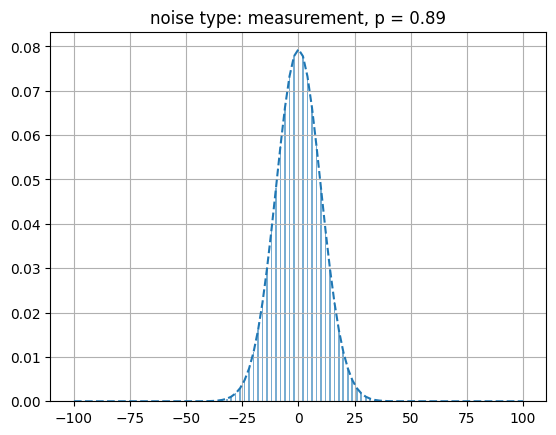

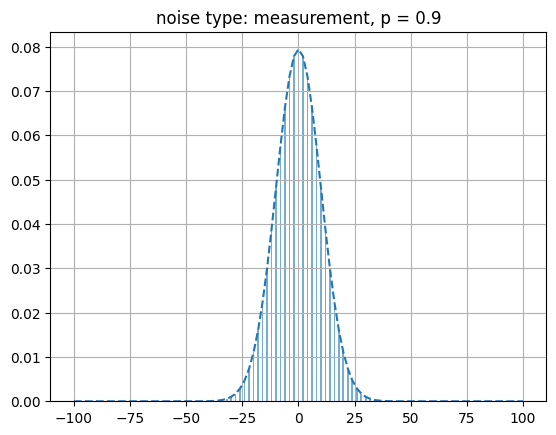

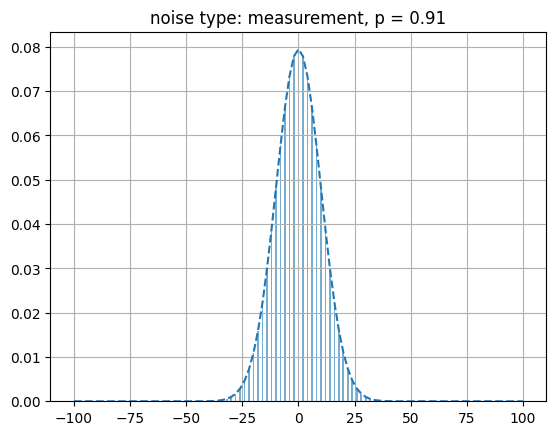

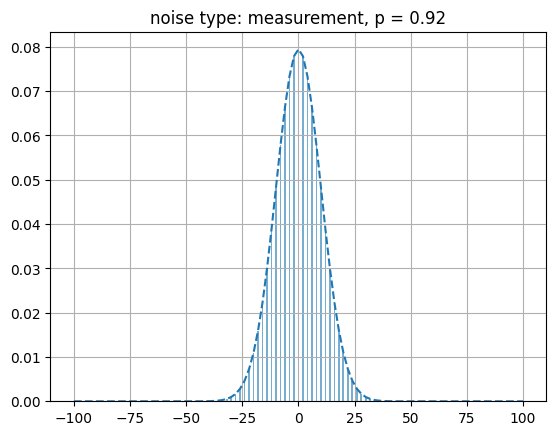

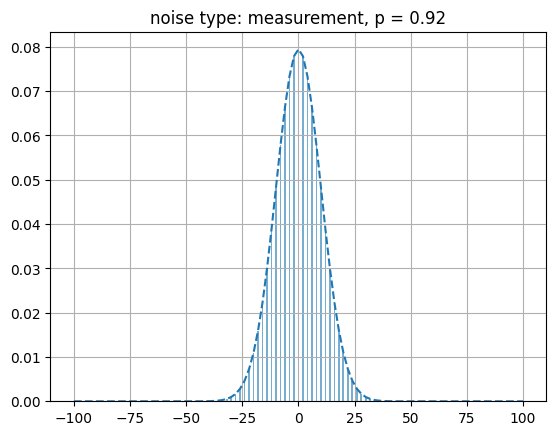

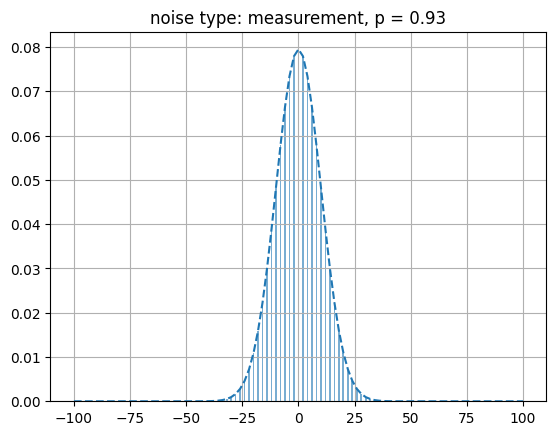

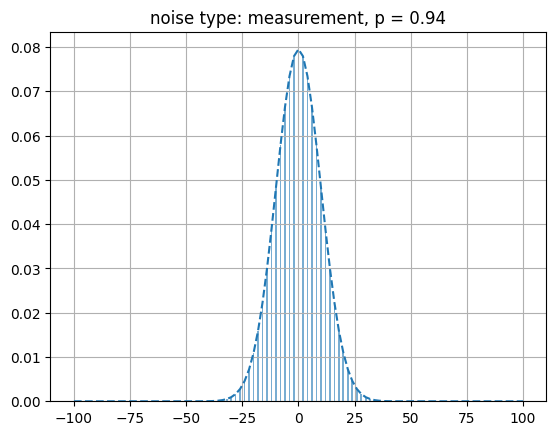

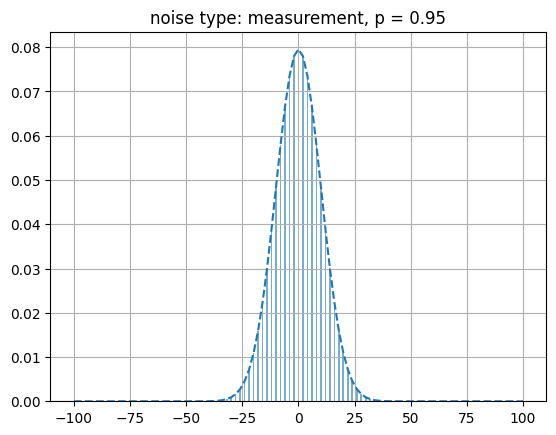

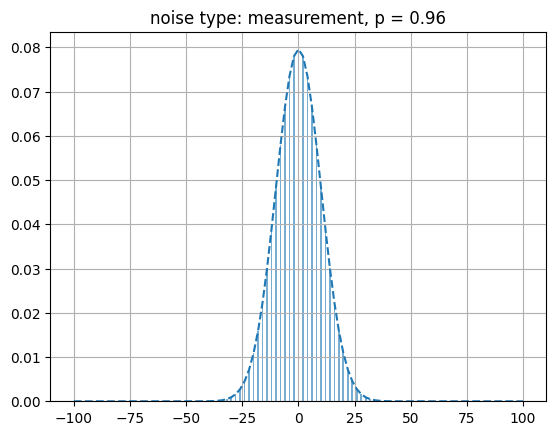

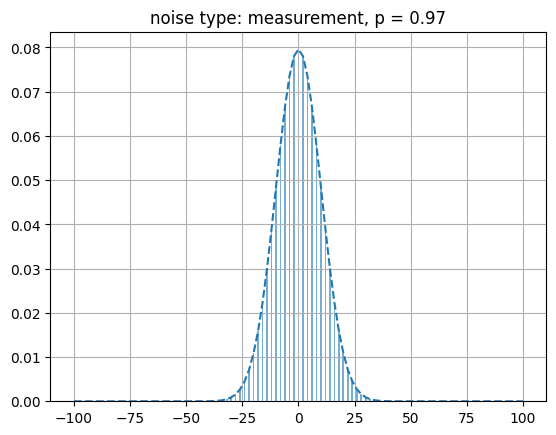

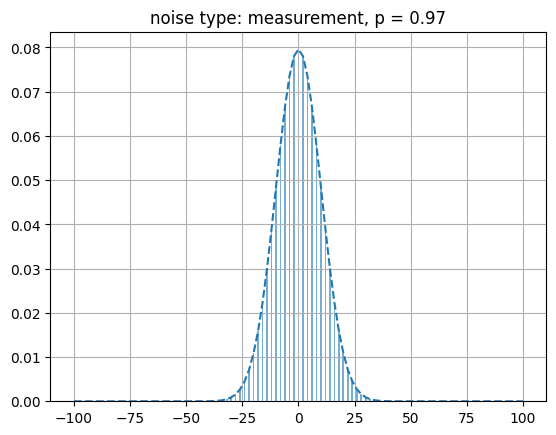

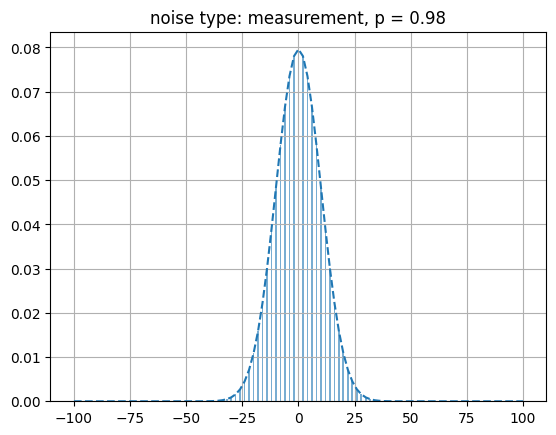

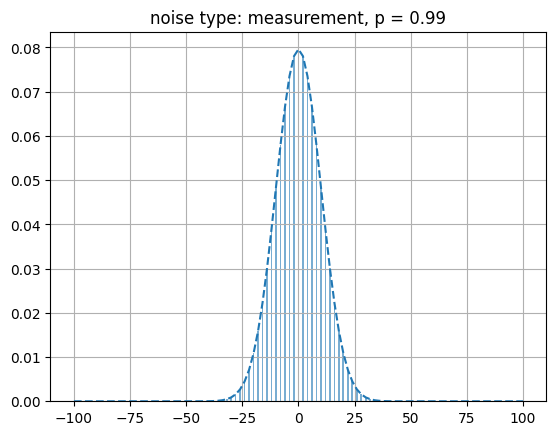

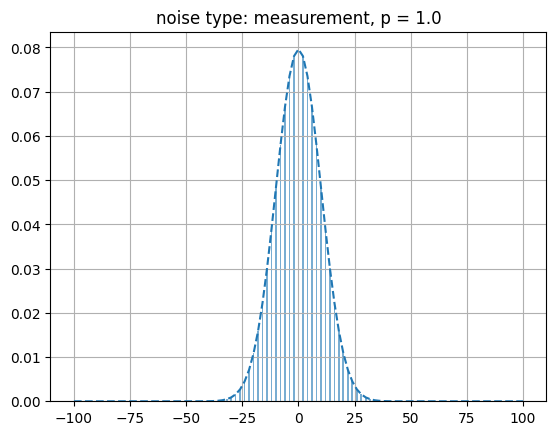

In [2]:
max_pos = 100
steps = 100
symm_qrw = True
SEED = 42



TIMES = 200
exp_name = "noisy_walk_meas"

_, X = noisy_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, 'H', 0, None) # just to have the X dim

P = np.linspace(0.89,1,14).round(2)

print(P)
for p in P:
    dists = []
    with open(f"./data/{exp_name}/{exp_name}_p_{p}.csv", "w") as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(X)
        np.random.seed(SEED)
        for t in range(TIMES):
            data, X = noisy_meas_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, p, None)
            Y = data[-1]
            X_odd = X[::2]
            Y_odd = Y[0::2]
            dists.append(Y)
            csvwriter.writerow(Y)
        arr_dists = np.array(dists)
        arr_sum = np.sum(arr_dists, 0)
        Y = arr_sum / TIMES
        Y = Y/np.sum(Y)
        X_odd = X[::2]
        Y_odd = Y[0::2]

    with open(f"./data/{exp_name}/{exp_name}_p_{p}_mean.csv", "w") as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(X)
        csvwriter.writerow(Y)

    plt.grid(True, which='major')
    plt.bar(X, Y, alpha=0.6)
    plt.plot(X_odd, Y_odd, '--')
    plt.title(f"noise type: measurement, p = {p}")    
    plt.savefig(f"./data/{exp_name}/{exp_name}_p_{p}_mean.pdf")
    plt.show()